### 📊 Demand Exploratory Data Analysis (EDA)

Project Context: This analysis focuses on ticket demand and operational efficiency across three key teams: KYC, Payments, and Sanctions. The goal is to establish a baseline for our forecasting models.

##### 🔍 Data Quality & Assumptions

The dataset is intentionally structured to reflect a mature Data Warehouse output, ensuring high integrity from the start. This allows us to shift our focus from data cleaning to high-value operational insights.

📈 Time-Series Patterns: Identifying multi-year growth and seasonal seasonality (weekly/monthly).

⚠️ Operational Bottlenecks: Evaluating the Backlog (represented by the ~5% of 'Open' status tickets).

⚙️ Resource Optimization: Mapping demand spikes to improve staffing and capacity planning.

[!NOTE]
Initial Validation: df.info() confirms a robust dataset of 60,000 entries. The presence of nulls in resolved_at is expected and mathematically consistent with the number of 'Open' tickets, confirming a healthy data ingestion process.

##### 📦 1. Infrastructure

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

##### 📥 2. Data Ingestion

In [64]:
df = pd.read_csv('../data/tickets_raw.csv')

In [65]:
df.columns

Index(['ticket_id', 'created_at', 'team', 'priority', 'status', 'resolved_at'], dtype='object')

In [66]:
df.head(2)

,ticket_id,created_at,team,priority,status,resolved_at
0,TKT-1001,2024-01-01 03:10:27.940868832,Sanctions,High,Resolved,2024-01-01 03:31:35.769210612
1,TKT-1002,2024-01-01 03:19:04.656630680,Sanctions,High,Resolved,2024-01-01 03:43:35.931614900


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ticket_id    60000 non-null  object
 1   created_at   60000 non-null  object
 2   team         60000 non-null  object
 3   priority     60000 non-null  object
 4   status       60000 non-null  object
 5   resolved_at  57039 non-null  object
dtypes: object(6)
memory usage: 2.7+ MB


In [68]:
df.describe()

,ticket_id,created_at,team,priority,status,resolved_at
count,60000,60000,60000,60000,60000,57039
unique,60000,60000,3,2,2,57039
top,TKT-1001,2024-01-01 03:10:27.940868832,KYC,Low,Resolved,2024-01-01 03:31:35.769210612
freq,1,1,29763,33521,57039,1


##### 🛠️ 3. Feature Engineering

In [69]:
# Convert timestamp strings to datetime objects
df['created_at'] = pd.to_datetime(df['created_at'])
df['resolved_at'] = pd.to_datetime(df['resolved_at'])

In [70]:
# Extract time-based features for multi-level reporting
df['year'] = df['created_at'].dt.year
df['quarter'] = df['created_at'].dt.quarter
df['month'] = df['created_at'].dt.month
df['hour'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.day_name()
df['month_year'] = df['created_at'].dt.to_period('M')
df['is_weekend'] = df['created_at'].dt.dayofweek >= 5


In [71]:
# Calculate Resolution time in minutes, only for resolved tickets
df['resolution_time_min'] = (df['resolved_at'] - df['created_at']).dt.total_seconds() / 60

In [72]:
# Data Sanity Check: Ensure resolution time is never negative 

df[df['resolution_time_min'] < 0]

,ticket_id,created_at,team,priority,status,resolved_at,year,quarter,month,hour,day_of_week,month_year,is_weekend,resolution_time_min


In [73]:
df.head()

,ticket_id,created_at,team,priority,status,resolved_at,year,quarter,month,hour,day_of_week,month_year,is_weekend,resolution_time_min
0,TKT-1001,2024-01-01 03:10:27.940868832,Sanctions,High,Resolved,2024-01-01 03:31:35.769210612,2024,1,1,3,Monday,2024-01,False,21.130472
1,TKT-1002,2024-01-01 03:19:04.656630680,Sanctions,High,Resolved,2024-01-01 03:43:35.931614900,2024,1,1,3,Monday,2024-01,False,24.521250
2,TKT-1003,2024-01-01 04:25:15.728091022,Payments,High,Resolved,2024-01-01 07:44:44.581443022,2024,1,1,4,Monday,2024-01,False,199.480889
3,TKT-1004,2024-01-01 04:46:49.017136599,Sanctions,High,Resolved,2024-01-01 05:04:13.032096819,2024,1,1,4,Monday,2024-01,False,17.400249
4,TKT-1005,2024-01-01 04:47:41.362879336,Payments,Low,Resolved,2024-01-01 07:19:15.972875176,2024,1,1,4,Monday,2024-01,False,151.576833


#### 📊 4. Operational Insights & Visualizations

In [74]:
# Resolution Time by Team
display(df.groupby('team')['resolution_time_min'].describe().round(2))


,count,mean,std,min,25%,50%,75%,max
team,,,,,,,,
KYC,28287.0,100.0,36.19,1.00,71.05,97.43,125.86,256.17
Payments,23044.0,180.0,141.40,1.00,86.98,155.46,235.82,1499.33
Sanctions,5708.0,25.0,8.64,14.98,20.56,22.03,23.93,98.92


In [75]:
# Priority Impact
display(df.groupby('priority')['resolution_time_min'].describe().round(2))

,count,mean,std,min,25%,50%,75%,max
priority,,,,,,,,
High,25196.0,99.64,77.45,1.0,39.60,74.23,150.08,703.76
Low,31843.0,144.74,120.57,1.0,83.76,114.78,152.82,1499.33


**Comments**

**Team Efficiency & Performance**

*   **Sanctions (High-Efficiency Benchmark):** This team is the most consistent and fast, with a 25-minute average resolution time. The low volatility (8.64 Std Dev) indicates a highly standardized and stable workflow.
*   **Payments (Process Bottleneck):** This area presents the most significant operational challenge. With a 180-minute average and high variance (141.40 Std Dev), it faces the toughest bottlenecks. Tickets reaching 1,499 minutes suggest complex manual dependencies or systemic blocks.
*   **KYC (High Volume Management):** KYC handles the largest workload with 28,287 cases. Despite this volume, they maintain steady performance with a median resolution time of approximately 97 minutes.

**Priority Impact**

*   **Triage Effectiveness:** The prioritization system is functional. High Priority tickets are processed 45% faster than Low Priority ones (99.64 min vs 144.74 min).
*   **Complexity Variance:** Priority level does not eliminate all delays. High Priority cases still show outliers reaching 703 minutes, indicating that individual case complexity can occasionally override priority status.
*   **Workload Distribution:** The demand is relatively balanced, although Low Priority tickets represent a larger portion of the total volume (31,843) compared to High Priority (25,196).

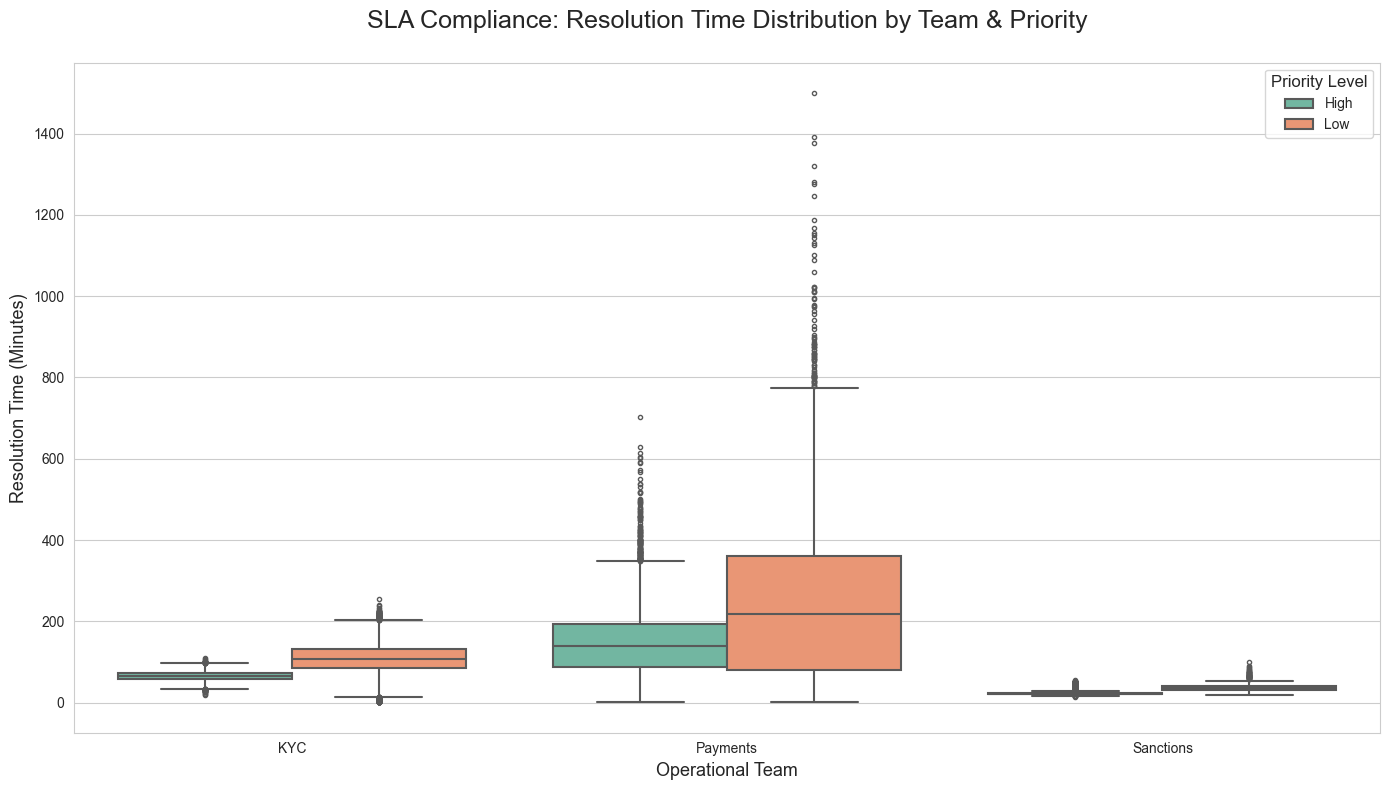

In [ ]:
# Resolution Time Distribution
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

team_order = ['KYC', 'Payments', 'Sanctions']
ax = sns.boxplot(
    data=df, 
    x='team', 
    y='resolution_time_min', 
    hue='priority', 
    order=team_order,
    palette='Set2',
    fliersize=3,  
    linewidth=1.5
)

plt.title('Resolution Time Distribution by Team & Priority', pad=25, fontsize=18)
plt.ylabel('Resolution Time (Minutes)', fontsize=13)
plt.xlabel('Operational Team', fontsize=13)
plt.legend(title='Priority Level', title_fontsize='12', loc='upper right')

# upper_limit = df['resolution_time_min'].quantile(0.95)
#plt.ylim(0, upper_limit) 

plt.tight_layout()
plt.show()

**Comments**

**Resolution Time Distribution by Team**

*   **Extreme Variance in Payments:** The boxplot clearly highlights that the **Payments** team faces the most significant operational instability. Both High and Low priority tickets show a massive spread, with dozens of outliers stretching towards the 1,500-minute mark.
*   **Priority Impact Consistency:** Across all teams, we can visually confirm that **High Priority** (green) boxes are positioned lower than **Low Priority** (orange) boxes, confirming that the faster resolution for critical tickets is a consistent trend, not an average skewed by a few cases.
*   **Sanctions Stability:** The "flatness" of the **Sanctions** boxes compared to the others is striking. This confirms an extremely standardized process with almost zero deviation, regardless of priority.
*   **KYC Reliability:** While KYC has a higher volume, their resolution times remain tightly clustered. The gap between priorities is clear, and the number of outliers is minimal compared to the Payments team.

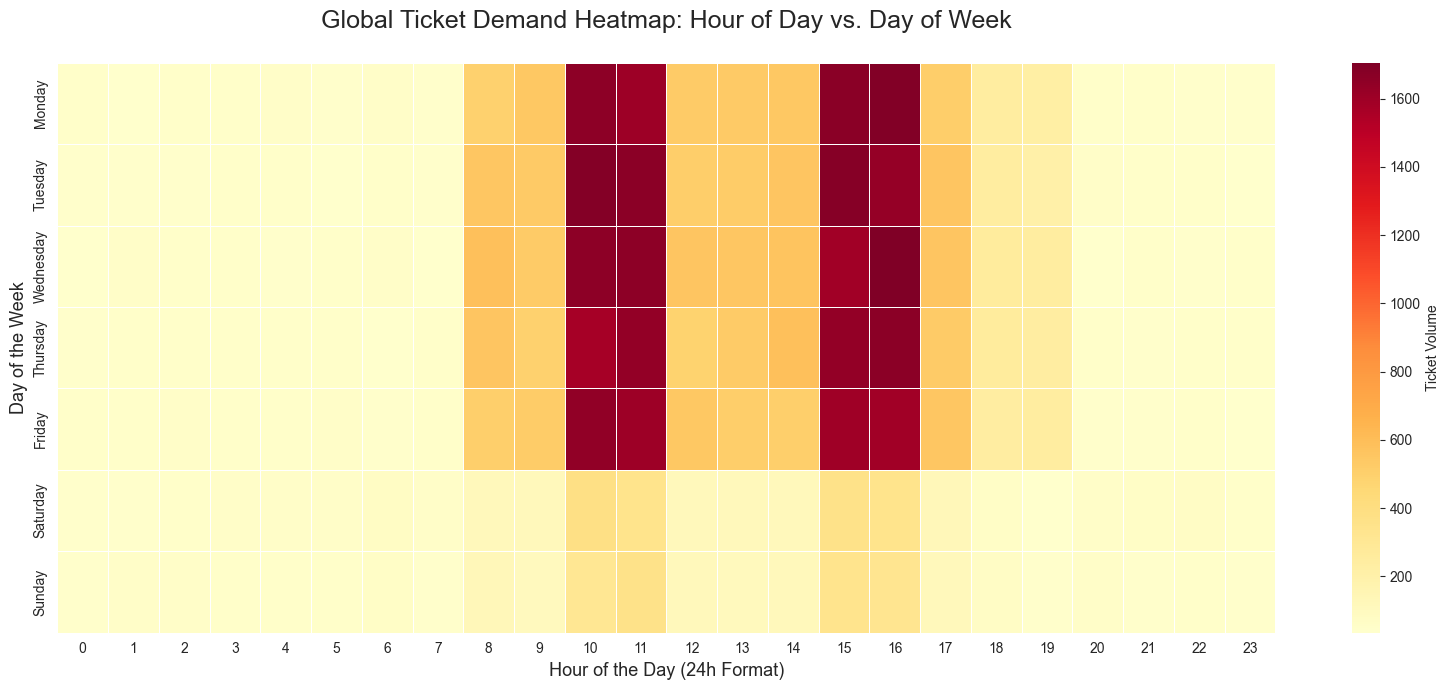

In [ ]:
# Ticket Demand Heatmap

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = df.pivot_table(
    index='day_of_week', 
    columns='hour', 
    values='ticket_id', 
    aggfunc='count'
).reindex(days_order).fillna(0)

# Professional Styling
plt.figure(figsize=(16, 7))
sns.set_style("white")

sns.heatmap(
    heatmap_data, 
    cmap='YlOrRd', 
    annot=False, 
    linewidths=.5,
    cbar_kws={'label': 'Ticket Volume'}
)

# Titles and Labels
plt.title('Global Ticket Demand Heatmap: Hour of Day vs. Day of Week', pad=25, fontsize=18)
plt.xlabel('Hour of the Day (24h Format)', fontsize=13)
plt.ylabel('Day of the Week', fontsize=13)

plt.tight_layout()
plt.show()

**Comments**

**Temporal Demand Patterns**

*   **Daily Double Peak:** There is a clear demand pattern during weekdays. The first peak occurs between **10:00 and 11:00**, followed by a second, equally intense surge between **15:00 and 16:00**.
*   **The Mid-day Lull:** A noticeable drop in ticket volume occurs between **12:00 and 14:00**. This suggests a synchronization with standard lunch breaks or a shift in user activity.
*   **Weekend Drop-off:** Demand plummet on Saturdays and Sundays. The few tickets that do arrive are concentrated in the same peak hours but at a fraction of the weekday volume, allowing for minimal weekend staffing.
*   **Operational Predictability:** The consistency across Monday to Friday is remarkable. The "heat" starts exactly at **08:00** and cools down rapidly after **17:00**, indicating that the business operates on a very strict, standard schedule.

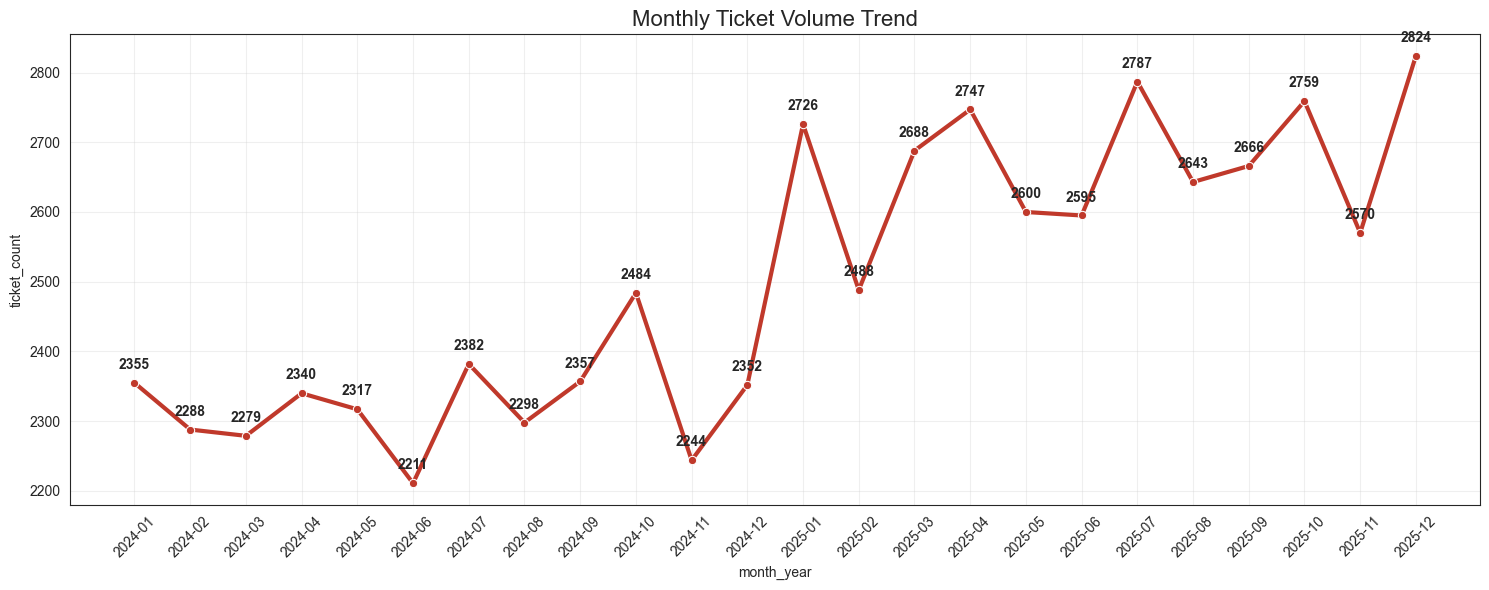

In [ ]:
# Trend on monthly ticket volume 

monthly_trend = df.groupby('month_year').size().reset_index(name='ticket_count')


monthly_trend['month_year'] = monthly_trend['month_year'].astype(str)
monthly_trend = monthly_trend.sort_values('month_year')

plt.figure(figsize=(15, 6))

sns.lineplot(
    data=monthly_trend, 
    x='month_year', 
    y='ticket_count', 
    marker='o', 
    linewidth=3, 
    color='#c0392b'
)

for i, row in monthly_trend.iterrows():
    plt.annotate(
        f"{row['ticket_count']}", 
        (row['month_year'], row['ticket_count']),
        textcoords="offset points", 
        xytext=(0,10), 
        ha='center', 
        fontweight='bold'
    )

plt.title('Monthly Ticket Volume Trend', fontsize=16)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Comments**

**Monthly Ticket Volume Trend**

*   **Consistent Growth Trend:** The business has seen a clear upward trajectory over the last 24 months. We started January 2024 with **2,355** tickets and closed December 2025 with a record high of **2,824** tickets a **20% increase** in total monthly volume.
*   **Identified Seasonality:** There is a recurring pattern where volume tends to dip in the middle of the year (June/August) and surge toward the end of the year and Q1. The jump between **December 2024 (2,352)** and **January 2025 (2,726)** is particularly sharp, suggesting a strong start-of-year peak.
*   **Increased Volatility:** The "swings" in 2025 are much more aggressive than in 2024. This higher variance makes manual staffing estimates unreliable and reinforces the need for a statistical model.
*   **Forecasting Justification:** Since the trend is not linear and shows clear seasonal components, simple averages won't work. We need **Holt-Winters** to capture the seasonality and **ARIMA** to handle the trend and autocorrelations.

# 🏁 Final Summary & Conclusions

> This analysis synthesizes findings from team performance metrics, distribution analysis, demand patterns, and long-term growth trends.

### 1. Operational Performance
*   **Team Efficiency:** We identified a significant performance gap between teams. While **Sanctions** operates as a high-efficiency benchmark (25 min avg), **Payments** represents a major bottleneck with extreme volatility and outliers reaching nearly 1,500 minutes.
*   **Triage Success:** The prioritization system is consistently effective across all teams. High Priority tickets are resolved 45% faster than Low Priority ones, though individual case complexity remains a factor that can cause delays even in critical tasks.

### 2. Temporal Demand & Growth Trends
*   **Daily Cycles:** Weekday demand follows a predictable "Double Peak" pattern (10:00-11:00 and 15:00-16:00), with a noticeable lull during mid-day. Weekends show minimal activity, allowing for leaner staffing.
*   **Long-term Trajectory:** The business is in a clear growth phase, with a **20% increase** in monthly volume over the last 24 months, reaching a peak of 2,824 tickets in late 2025.
*   **Seasonality:** A sharp volume surge is evident at the start of each year, accompanied by increased volatility in 2025.

### 🚀 Final Conclusion for Forecasting
The current manual staffing approach is becoming unsustainable due to **growing ticket volumes** and **increasing volatility**. To maintain SLA compliance—especially within the **Payments** team—we must implement advanced modeling. 

The clear daily and annual seasonality identified justifies moving to **Holt-Winters** and **ARIMA** models to accurately predict future peaks and optimize resource allocation.